# Comprehensive Evaluation of Trained YOLOv5 Models on Train, Validation, and Test Splits

This notebook provides a reproducible evaluation workflow for all trained YOLOv5 experiments found under `yolov5/runs/train/`.

## Scope
- Discover all experiment directories and collect available `best.pt` checkpoints.
- Evaluate every checkpoint on all three dataset splits (`train`, `val`, and `test`) using `val.py`.
- Print per-run, per-class metrics in a consistent tabular format:
  - `cls`, `Images`, `Instances`, `P`, `R`, `mAP50`, `mAP50-95`
- Aggregate and compare model-level summary metrics from the `all` row.
- Generate qualitative prediction outputs with `detect.py` (test split) and visualize sample images.

## Reproducibility Notes
- Evaluation output directories are timestamped with `RUN_TAG` to avoid collisions.
- The notebook validates required paths and dataset fields before execution.
- Unsupported experiment datasets are explicitly skipped and reported.


## 1. Define Core Paths and Runtime Constants

This section initializes all primary filesystem paths and runtime constants used by the notebook.

### What is defined
- Project root and YOLOv5 root
- Dataset YAML path
- Training runs directory
- Python executable used to call `val.py` and `detect.py`
- Timestamp tag (`RUN_TAG`) for unique output directory names
- A fixed class display order for per-class metric reporting

### Why this matters
Centralizing these values makes the workflow easier to audit, update, and reproduce.


In [41]:
from pathlib import Path
import subprocess
import os
from datetime import datetime
import sys
import re

import yaml
from PIL import Image
import matplotlib.pyplot as plt

# Project root
PROJECT_ROOT = Path('/workspace/dl_project/project_yolov5')
# YOLOv5 root
YOLO_ROOT = PROJECT_ROOT / 'yolov5'
# Dataset YAML
DATA_YAML = YOLO_ROOT / 'data' / 'StudentWatch.yaml'
# Training runs directory
TRAIN_RUNS_DIR = YOLO_ROOT / 'runs' / 'train'
# Timestamp used to avoid output directory name collisions
RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
PYTHON_EXEC = sys.executable

# Fixed print order for key classes
TARGET_CLS_ORDER = [
    'all',
    'bowing_the_head',
    'learning_over_the_table',
    'reading',
    'using_phone',
    'writing',
]

PROJECT_ROOT, YOLO_ROOT, DATA_YAML, TRAIN_RUNS_DIR, PYTHON_EXEC


(PosixPath('/workspace/dl_project/project_yolov5'),
 PosixPath('/workspace/dl_project/project_yolov5/yolov5'),
 PosixPath('/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch.yaml'),
 PosixPath('/workspace/dl_project/project_yolov5/yolov5/runs/train'),
 '/opt/conda/bin/python')

## 2. Validate Required Paths

This section performs strict preflight checks to ensure all required locations exist before any evaluation starts.

### Checks performed
- Project root exists
- YOLOv5 root exists
- Dataset YAML file exists
- Training runs directory exists

Fail-fast validation prevents long-running jobs from failing late due to path or configuration mistakes.


In [42]:
assert PROJECT_ROOT.exists(), f"PROJECT_ROOT not found: {PROJECT_ROOT}"
assert YOLO_ROOT.exists(), f"YOLO_ROOT not found: {YOLO_ROOT}"
assert DATA_YAML.exists(), f"DATA_YAML not found: {DATA_YAML}"
assert TRAIN_RUNS_DIR.exists(), f"TRAIN_RUNS_DIR not found: {TRAIN_RUNS_DIR}"
print('All key paths exist.')


All key paths exist.


## 3. Load Dataset Configuration and Resolve Split Directories

This section reads the dataset YAML and resolves absolute directories for all required evaluation splits.

### Resolution logic
- Load `path` from the YAML as dataset root.
- Resolve relative paths against the YAML directory when needed.
- Require and resolve `train`, `val`, and `test` split directories.
- Validate that each resolved split directory exists before continuing.

### Output
Printed absolute paths for dataset root and all required split image directories (`train`, `val`, `test`) for traceability.


In [43]:
with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

# Dataset root
data_root = Path(data_cfg['path'])
if not data_root.is_absolute():
    data_root = (DATA_YAML.parent / data_root).resolve()

# Required split paths from dataset YAML
required_split_keys = ('train', 'val', 'test')
missing_splits = [k for k in required_split_keys if k not in data_cfg]
assert not missing_splits, f"Missing required split(s) {missing_splits} in {DATA_YAML}"

train_rel = data_cfg['train']
val_rel = data_cfg['val']
test_rel = data_cfg['test']

# train / val / test image directories
train_images_dir = (data_root / train_rel).resolve()
val_images_dir = (data_root / val_rel).resolve()
test_images_dir = (data_root / test_rel).resolve()

assert data_root.exists(), f'data root not found: {data_root}'
assert train_images_dir.exists(), f'train images dir not found: {train_images_dir}'
assert val_images_dir.exists(), f'val images dir not found: {val_images_dir}'
assert test_images_dir.exists(), f'test images dir not found: {test_images_dir}'

print('data root     :', data_root)
print('train field   :', train_rel)
print('train images  :', train_images_dir)
print('val field     :', val_rel)
print('val images    :', val_images_dir)
print('test field    :', test_rel)
print('test images   :', test_images_dir)


data root     : /workspace/dl_project/project_yolov5/dataset/yolov5/sb
train field   : train/images
train images  : /workspace/dl_project/project_yolov5/dataset/yolov5/sb/train/images
val field     : valid/images
val images    : /workspace/dl_project/project_yolov5/dataset/yolov5/sb/valid/images
test field    : test/images
test images   : /workspace/dl_project/project_yolov5/dataset/yolov5/sb/test/images


Dataset source: /workspace/dl_project/project_yolov5/yolov5/data/StudentWatch.yaml
Dataset root  : /workspace/dl_project/project_yolov5/dataset/yolov5/sb
Image counts  : {'train': 235, 'val': 67, 'test': 33} | total = 335
Class counts  : {'bowing_the_head': 475, 'hand_raising': 16, 'learning_over_the_table': 514, 'reading': 3906, 'using_phone': 3488, 'writing': 1488}


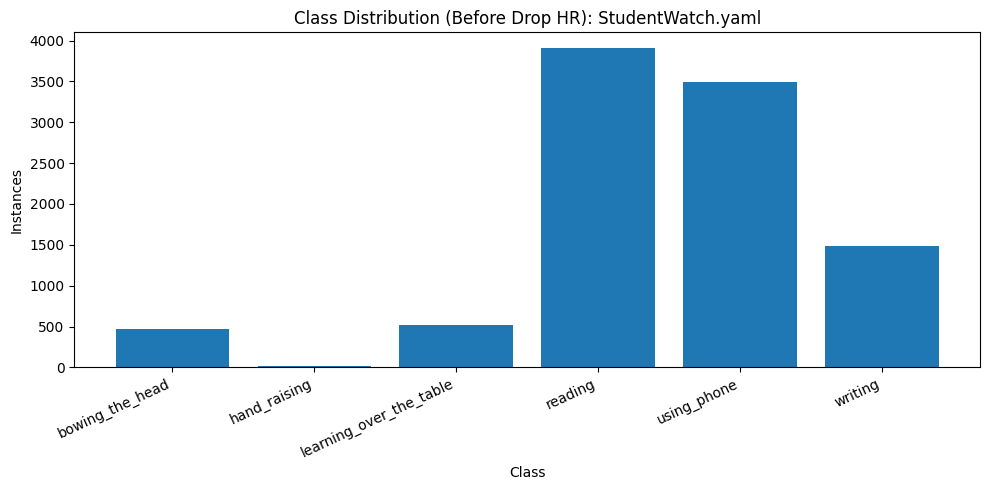

In [44]:
# Class distribution before dropping hand_raising (StudentWatch.yaml)
from collections import Counter

with open(YOLO_ROOT / 'data' / 'StudentWatch.yaml', 'r', encoding='utf-8') as f:
    ds_before = yaml.safe_load(f)

base_before = Path(ds_before['path'])
if not base_before.is_absolute():
    base_before = (YOLO_ROOT / 'data' / base_before).resolve()

img_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
class_counts_before = Counter()
split_image_counts_before = {}

for split in ['train', 'val', 'test']:
    img_dir = (base_before / ds_before[split]).resolve()
    lbl_dir = Path(str(img_dir).replace('/images', '/labels'))

    n_images = sum(1 for p in img_dir.rglob('*') if p.suffix.lower() in img_exts)
    split_image_counts_before[split] = n_images

    for lp in lbl_dir.rglob('*.txt'):
        for line in lp.read_text(encoding='utf-8', errors='ignore').splitlines():
            line = line.strip()
            if not line:
                continue
            cid = int(float(line.split()[0]))
            class_counts_before[cid] += 1

name_map_before = dict(ds_before['names'])
ordered_ids_before = sorted(name_map_before.keys())
labels_before = [name_map_before[i] for i in ordered_ids_before]
values_before = [class_counts_before.get(i, 0) for i in ordered_ids_before]

print('Dataset source:', YOLO_ROOT / 'data' / 'StudentWatch.yaml')
print('Dataset root  :', base_before)
print('Image counts  :', split_image_counts_before, '| total =', sum(split_image_counts_before.values()))
print('Class counts  :', {name_map_before[i]: class_counts_before.get(i, 0) for i in ordered_ids_before})

plt.figure(figsize=(10, 5))
plt.bar(labels_before, values_before)
plt.title('Class Distribution (Before Drop HR): StudentWatch.yaml')
plt.xlabel('Class')
plt.ylabel('Instances')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


Dataset source: /workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml
Dataset root  : /workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr
Image counts  : {'train': 235, 'val': 67, 'test': 33} | total = 335
Class counts  : {'bowing_the_head': 475, 'learning_over_the_table': 514, 'reading': 3906, 'using_phone': 3488, 'writing': 1488}


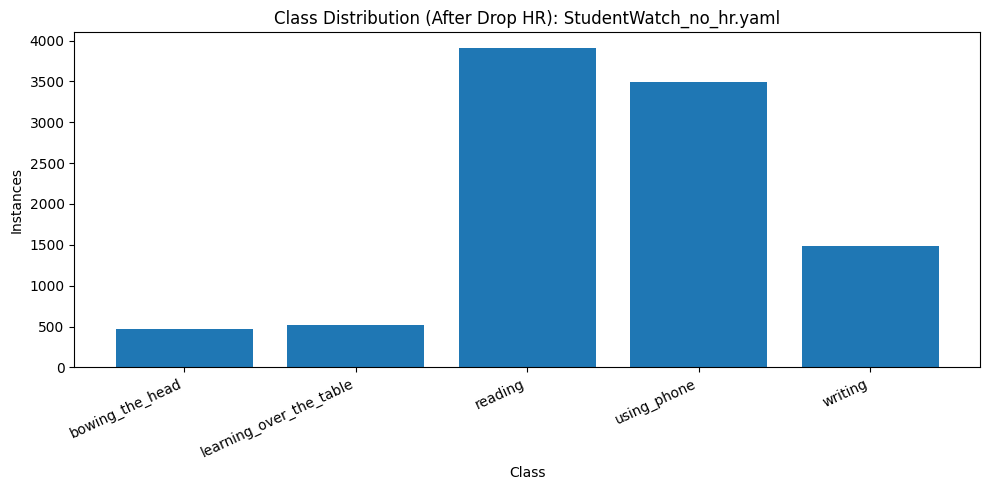

In [45]:
# Class distribution after dropping hand_raising (StudentWatch_no_hr.yaml)
from collections import Counter

with open(YOLO_ROOT / 'data' / 'StudentWatch_no_hr.yaml', 'r', encoding='utf-8') as f:
    ds_after = yaml.safe_load(f)

base_after = Path(ds_after['path'])
if not base_after.is_absolute():
    base_after = (YOLO_ROOT / 'data' / base_after).resolve()

img_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
class_counts_after = Counter()
split_image_counts_after = {}

for split in ['train', 'val', 'test']:
    img_dir = (base_after / ds_after[split]).resolve()
    lbl_dir = Path(str(img_dir).replace('/images', '/labels'))

    n_images = sum(1 for p in img_dir.rglob('*') if p.suffix.lower() in img_exts)
    split_image_counts_after[split] = n_images

    for lp in lbl_dir.rglob('*.txt'):
        for line in lp.read_text(encoding='utf-8', errors='ignore').splitlines():
            line = line.strip()
            if not line:
                continue
            cid = int(float(line.split()[0]))
            class_counts_after[cid] += 1

name_map_after = dict(ds_after['names'])
ordered_ids_after = sorted(name_map_after.keys())
labels_after = [name_map_after[i] for i in ordered_ids_after]
values_after = [class_counts_after.get(i, 0) for i in ordered_ids_after]

print('Dataset source:', YOLO_ROOT / 'data' / 'StudentWatch_no_hr.yaml')
print('Dataset root  :', base_after)
print('Image counts  :', split_image_counts_after, '| total =', sum(split_image_counts_after.values()))
print('Class counts  :', {name_map_after[i]: class_counts_after.get(i, 0) for i in ordered_ids_after})

plt.figure(figsize=(10, 5))
plt.bar(labels_after, values_after)
plt.title('Class Distribution (After Drop HR): StudentWatch_no_hr.yaml')
plt.xlabel('Class')
plt.ylabel('Instances')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()


## 4. Set Working Directory to YOLOv5 Root

This section switches the current working directory to the YOLOv5 root.

Running `val.py` and `detect.py` from a consistent working directory avoids path resolution issues and keeps command behavior deterministic.


In [27]:
os.chdir(YOLO_ROOT)
print('Current working directory:', Path.cwd())


Current working directory: /workspace/dl_project/project_yolov5/yolov5


## 5. Discover Evaluation Jobs (Checkpoints × Splits)

This section scans `runs/train/*` and builds a complete job list.

### Discovery rules
- For each experiment, look for `weights/best.pt`.
- Read experiment-specific `opt.yaml` (when available) to recover the original dataset YAML.
- Keep only supported datasets (`StudentWatch.yaml`, `StudentWatch_no_hr.yaml`).
- Require all three split keys (`train`, `val`, `test`) in each dataset YAML.
- Build three evaluation jobs per checkpoint:
  - `task=train`
  - `task=val`
  - `task=test`

### Output
- `weight_jobs`: executable evaluation jobs
- `skipped_jobs`: unsupported or invalid experiments with explicit reasons


In [28]:
weight_jobs = []
skipped_jobs = []

# Evaluate only StudentWatch-related experiments.
allowed_data_yamls = {
    (YOLO_ROOT / "data" / "StudentWatch.yaml").resolve(),
    (YOLO_ROOT / "data" / "StudentWatch_no_hr.yaml").resolve(),
}

required_split_keys = ("train", "val", "test")

# Iterate over all training experiment folders.
for exp_dir in sorted(TRAIN_RUNS_DIR.iterdir()):
    if not exp_dir.is_dir():
        continue

    weights_dir = exp_dir / "weights"
    if not weights_dir.exists():
        continue

    # Prefer each experiment's opt.yaml to recover the dataset config used in training.
    opt_yaml = exp_dir / "opt.yaml"
    if opt_yaml.exists():
        with open(opt_yaml, 'r', encoding='utf-8') as f:
            opt_cfg = yaml.safe_load(f)
        data_yaml_for_exp = Path(opt_cfg.get('data', DATA_YAML))
        if not data_yaml_for_exp.is_absolute():
            data_yaml_for_exp = (YOLO_ROOT / data_yaml_for_exp).resolve()
    else:
        data_yaml_for_exp = DATA_YAML.resolve()

    data_yaml_for_exp = data_yaml_for_exp.resolve()

    if data_yaml_for_exp not in allowed_data_yamls:
        skipped_jobs.append({
            "exp_name": exp_dir.name,
            "reason": f"unsupported data yaml: {data_yaml_for_exp}",
        })
        continue

    assert data_yaml_for_exp.exists(), f"data yaml not found for {exp_dir.name}: {data_yaml_for_exp}"

    with open(data_yaml_for_exp, 'r', encoding='utf-8') as f:
        exp_data_cfg = yaml.safe_load(f)

    exp_data_root = Path(exp_data_cfg['path'])
    if not exp_data_root.is_absolute():
        exp_data_root = (data_yaml_for_exp.parent / exp_data_root).resolve()
    else:
        exp_data_root = exp_data_root.resolve()

    assert exp_data_root.exists(), f"data root not found for {exp_dir.name}: {exp_data_root}"

    missing_splits = [k for k in required_split_keys if k not in exp_data_cfg]
    assert not missing_splits, (
        f"Missing required split(s) {missing_splits} in {data_yaml_for_exp}. "
        "This notebook requires train/val/test for every model."
    )

    split_to_images_dir = {}
    for split_key in required_split_keys:
        split_images_dir = (exp_data_root / exp_data_cfg[split_key]).resolve()
        assert split_images_dir.exists(), (
            f"{split_key} images dir not found for {exp_dir.name}: {split_images_dir}"
        )
        split_to_images_dir[split_key] = split_images_dir

    # Check best.pt only.
    for weight_name in ["best.pt"]:
        weight_path = weights_dir / weight_name
        if not weight_path.exists():
            continue

        # Evaluate each model on train, val, and test splits.
        for eval_task in required_split_keys:
            weight_jobs.append({
                "exp_name": exp_dir.name,
                "weight_type": weight_name.replace(".pt", ""),
                "weight_path": weight_path.resolve(),
                "data_yaml": data_yaml_for_exp,
                "eval_task": eval_task,
                "data_split_key": eval_task,
                "source_images_dir": split_to_images_dir[eval_task],
                "test_images_dir": split_to_images_dir["test"],
            })

assert weight_jobs, "No compatible best.pt weights found under runs/train."

print(f"Collected {len(weight_jobs)} evaluation jobs:")
for job in weight_jobs:
    print(
        f"- {job['exp_name']} | {job['weight_type']} | {job['weight_path']} | "
        f"task={job['eval_task']} (yaml key={job['data_split_key']}) | "
        f"images={job['source_images_dir']}"
    )

if skipped_jobs:
    print("\nSkipped experiments:")
    for item in skipped_jobs:
        print(f"- {item['exp_name']} | {item['reason']}")


Collected 45 evaluation jobs:
- sb_baseline | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_baseline/weights/best.pt | task=train (yaml key=train) | images=/workspace/dl_project/project_yolov5/dataset/yolov5/sb/train/images
- sb_baseline | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_baseline/weights/best.pt | task=val (yaml key=val) | images=/workspace/dl_project/project_yolov5/dataset/yolov5/sb/valid/images
- sb_baseline | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_baseline/weights/best.pt | task=test (yaml key=test) | images=/workspace/dl_project/project_yolov5/dataset/yolov5/sb/test/images
- sb_no_hr | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_no_hr/weights/best.pt | task=train (yaml key=train) | images=/workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/train/images
- sb_no_hr | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_no_hr/weights/best.pt | task=val (yaml key=val)

## 6. Run `val.py` for Every Job and Print Per-Class Metrics

This is the core evaluation stage.

### Execution behavior
For each job in `weight_jobs`, the notebook runs `val.py` with:
- The experiment-specific dataset YAML
- The selected checkpoint (`best`)
- The target evaluation task (`train`, `val`, or `test`)
- A dedicated output directory under `runs/eval_train_val_test/`

### Parsed metrics
The notebook parses class-level rows from `val.py` output and prints a standardized table containing:
- `cls`
- `Images`
- `Instances`
- `P`
- `R`
- `mAP50`
- `mAP50-95`

The class display order is fixed for key classes (`all`, `bowing_the_head`, `learning_over_the_table`, `reading`, `using_phone`, `writing`) and then extended with any additional classes if present.


In [29]:
val_results = []

# Parse per-class metric rows from val.py output: cls Images Instances P R mAP50 mAP50-95
metric_line_pattern = re.compile(
    r"^\s*(.+?)\s+(\d+)\s+(\d+)\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)"
    r"\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)"
    r"\s+([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)\s*$"
)


def parse_class_metrics_rows(output_text):
    parsed = []
    for raw_line in output_text.splitlines():
        line = raw_line.strip()
        if not line:
            continue
        m = metric_line_pattern.match(line)
        if not m:
            continue

        cls_name = m.group(1).strip()
        try:
            row = {
                'cls': cls_name,
                'Images': int(m.group(2)),
                'Instances': int(m.group(3)),
                'P': float(m.group(4)),
                'R': float(m.group(5)),
                'mAP50': float(m.group(6)),
                'mAP50_95': float(m.group(7)),
            }
        except ValueError:
            continue

        parsed.append(row)

    # Deduplicate by class name while keeping output order and the latest value.
    row_map = {}
    row_order = []
    for row in parsed:
        cls_name = row['cls']
        if cls_name not in row_map:
            row_order.append(cls_name)
        row_map[cls_name] = row

    return [row_map[c] for c in row_order]


def _fmt_float(v):
    if v is None:
        return '-'
    return f"{v:.3f}"


def print_class_metrics_table(metric_rows, title):
    print("\n" + "=" * 110)
    print(title)

    header = f"{'cls':<28} {'Images':>8} {'Instances':>10} {'P':>10} {'R':>10} {'mAP50':>10} {'mAP50-95':>10}"
    print(header)
    print("-" * len(header))

    row_map = {row['cls']: row for row in metric_rows}
    printed = set()

    # Print priority classes first.
    for cls_name in TARGET_CLS_ORDER:
        row = row_map.get(cls_name)
        printed.add(cls_name)
        if row is None:
            print(f"{cls_name:<28} {'-':>8} {'-':>10} {'-':>10} {'-':>10} {'-':>10} {'-':>10}")
            continue
        print(
            f"{cls_name:<28} {row['Images']:>8d} {row['Instances']:>10d} "
            f"{_fmt_float(row['P']):>10} {_fmt_float(row['R']):>10} "
            f"{_fmt_float(row['mAP50']):>10} {_fmt_float(row['mAP50_95']):>10}"
        )

    # Then print any extra classes not in TARGET_CLS_ORDER.
    for row in metric_rows:
        cls_name = row['cls']
        if cls_name in printed:
            continue
        print(
            f"{cls_name:<28} {row['Images']:>8d} {row['Instances']:>10d} "
            f"{_fmt_float(row['P']):>10} {_fmt_float(row['R']):>10} "
            f"{_fmt_float(row['mAP50']):>10} {_fmt_float(row['mAP50_95']):>10}"
        )


def print_evaluation_plan(jobs):
    grouped = {}
    for job in jobs:
        key = (job['exp_name'], job['weight_type'])
        if key not in grouped:
            grouped[key] = {}
        grouped[key][job['eval_task']] = job['data_split_key']

    print("\nEvaluation plan by checkpoint:")
    for (exp_name, weight_type), task_map in grouped.items():
        for task in ('train', 'val', 'test'):
            yaml_key = task_map.get(task)
            if yaml_key is None:
                continue
            print(f"[{exp_name} | {weight_type}] task={task} (yaml key={yaml_key})")


print_evaluation_plan(weight_jobs)

for job in weight_jobs:
    # Generate a unique output directory name for each evaluation job.
    run_name = f"{job['exp_name']}_{job['weight_type']}_{job['eval_task']}_{RUN_TAG}"
    output_dir = YOLO_ROOT / "runs" / "eval_train_val_test" / run_name

    cmd = [
        str(PYTHON_EXEC), "val.py",
        "--data", str(job['data_yaml']),
        "--weights", str(job['weight_path']),
        "--img", "640",
        "--batch", "2",
        "--task", job['eval_task'],
        "--project", "runs/eval_train_val_test",
        "--name", run_name,
        "--save-txt",
        "--save-conf",
        "--verbose",
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, cwd=YOLO_ROOT)

    if result.returncode != 0:
        raise RuntimeError(
            f"val.py failed for {job['exp_name']} {job['weight_type']} {job['eval_task']} "
            f"with return code {result.returncode}"
        )

    # YOLOv5 often prints evaluation logs to stderr, so parse stdout + stderr together.
    combined_output = (result.stdout or "") + "\n" + (result.stderr or "")
    metric_rows = parse_class_metrics_rows(combined_output)
    if not metric_rows:
        raise RuntimeError(
            f"Could not parse class metrics for {job['exp_name']} {job['weight_type']} {job['eval_task']}"
        )

    title = (
        f"[{job['exp_name']} | {job['weight_type']}] task={job['eval_task']} "
        f"(yaml key={job['data_split_key']})"
    )
    print_class_metrics_table(metric_rows, title)

    val_results.append({
        **job,
        "run_name": run_name,
        "output_dir": output_dir,
        "stdout": result.stdout,
        "stderr": result.stderr,
        "metric_rows": metric_rows,
    })



Evaluation plan by checkpoint:
[sb_baseline | best] task=train (yaml key=train)
[sb_baseline | best] task=val (yaml key=val)
[sb_baseline | best] task=test (yaml key=test)
[sb_no_hr | best] task=train (yaml key=train)
[sb_no_hr | best] task=val (yaml key=val)
[sb_no_hr | best] task=test (yaml key=test)
[sb_no_hr_aug | best] task=train (yaml key=train)
[sb_no_hr_aug | best] task=val (yaml key=val)
[sb_no_hr_aug | best] task=test (yaml key=test)
[sb_no_hr_aug_weighted | best] task=train (yaml key=train)
[sb_no_hr_aug_weighted | best] task=val (yaml key=val)
[sb_no_hr_aug_weighted | best] task=test (yaml key=test)
[sb_no_hr_weighted | best] task=train (yaml key=train)
[sb_no_hr_weighted | best] task=val (yaml key=val)
[sb_no_hr_weighted | best] task=test (yaml key=test)
[sb_se_head_p4_no_hr | best] task=train (yaml key=train)
[sb_se_head_p4_no_hr | best] task=val (yaml key=val)
[sb_se_head_p4_no_hr | best] task=test (yaml key=test)
[sb_se_head_p4_p5_no_hr | best] task=train (yaml key=tra


[sb_baseline | best] task=train (yaml key=train)
cls                            Images  Instances          P          R      mAP50   mAP50-95
--------------------------------------------------------------------------------------------
all                               235       6899      0.990      0.815      0.873      0.742
bowing_the_head                   235        314      0.993      0.930      0.987      0.808
learning_over_the_table           235        361      0.986      0.987      0.993      0.790
reading                           235       2718      0.990      0.990      0.994      0.856
using_phone                       235       2466      0.990      0.994      0.995      0.868
writing                           235       1029      0.982      0.991      0.994      0.878
hand_raising                      235         11      1.000      0.000      0.277      0.249

[sb_baseline | best] task=val (yaml key=val)
cls                            Images  Instances          P        

## 7. List Validation Output Directories

This section lists all generated evaluation folders under `runs/eval_train_val_test/...`.

Use this output to quickly locate:
- Per-run logs
- Optional prediction text files
- Any artifacts produced by `val.py`


In [30]:
print('Validation output directories:')
# for item in val_results:
#     print(
#         f"- {item['exp_name']} ({item['weight_type']}, {item['eval_task']}): {item['output_dir']} | "
#         f"data={item['data_yaml']} | split={item['data_split_key']}"
#     )


Validation output directories:


In [31]:
performance_rows = []

for item in val_results:
    all_row = next((r for r in item.get('metric_rows', []) if r.get('cls') == 'all'), None)
    if all_row is None:
        print(
            f"Warning: could not find 'all' row for {item['exp_name']} "
            f"({item['weight_type']}, {item['eval_task']})"
        )
        continue

    performance_rows.append({
        "exp_name": item["exp_name"],
        "weight_type": item["weight_type"],
        "split": item["eval_task"],
        "P": all_row["P"],
        "R": all_row["R"],
        "mAP50": all_row["mAP50"],
        "mAP50-95": all_row["mAP50_95"],
    })

assert performance_rows, "No model performance could be parsed from val.py outputs."

# Sort once so all sub-tables and the overall table use the same ranking.
performance_rows = sorted(performance_rows, key=lambda x: x["mAP50-95"], reverse=True)


def print_performance_table(rows, title):
    print(title)
    if not rows:
        print("No rows to display")
        return

    header = f"{'model':<28} {'wt':<6} {'split':<6} {'P':>10} {'R':>10} {'mAP50':>10} {'mAP50-95':>12}"
    print(header)
    print("-" * len(header))
    for row in rows:
        print(
            f"{row['exp_name']:<28} {row['weight_type']:<6} {row['split']:<6} "
            f"{row['P']:>10.4f} {row['R']:>10.4f} {row['mAP50']:>10.4f} {row['mAP50-95']:>12.4f}"
        )


## 8.1 Baseline Subset

This section reports results only for the baseline experiment family.

### Run mapping
| TensorBoard Run | Script | SE Placement | Notes |
|---|---|---|---|
| `sb_baseline` | `shell_run/run_sb.sh` | None | Original YOLOv5 baseline |


In [32]:
baseline_rows = [row for row in performance_rows if row["exp_name"] == "sb_baseline"]
print_performance_table(baseline_rows, "Baseline only")


Baseline only
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_baseline                  best   train      0.9900     0.8150     0.8730       0.7420
sb_baseline                  best   test       0.9160     0.7390     0.8310       0.6410
sb_baseline                  best   val        0.9200     0.7420     0.7550       0.5970


## 8.2 Imbalanced-Data Handling Subset

This section reports results for experiments that address class imbalance without SE modules.

### Run mapping
| TensorBoard Run | Script | SE Placement | Notes |
|---|---|---|---|
| `sb_no_hr` | `shell_run/run_sb_no_hr.sh` | None | Drops `hand_raising` class |
| `sb_no_hr_aug` | `shell_run/run_sb_no_hr_aug.sh` | None | Drop class + augmentation |
| `sb_no_hr_weighted` | `shell_run/run_sb_no_hr_weighted.sh` | None | Drop class + weighted loss |
| `sb_no_hr_aug_weighted` | `shell_run/run_sb_no_hr_aug_weighted.sh` | None | Drop class + augmentation + weighted loss |


In [33]:
imbalance_rows = [
    row for row in performance_rows
    if row["exp_name"] in {"sb_no_hr", "sb_no_hr_aug", "sb_no_hr_weighted", "sb_no_hr_aug_weighted"}
]
print_performance_table(imbalance_rows, "Imbalanced data methods")


Imbalanced data methods
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_no_hr                     best   train      0.9910     0.9870     0.9920       0.8470
sb_no_hr_aug_weighted        best   train      0.9920     0.9860     0.9950       0.8410
sb_no_hr_weighted            best   train      0.9880     0.9830     0.9930       0.8400
sb_no_hr_aug                 best   train      0.9920     0.9860     0.9940       0.8250
sb_no_hr                     best   val        0.9020     0.8930     0.9000       0.7150
sb_no_hr_weighted            best   val        0.9020     0.8910     0.9050       0.7140
sb_no_hr_aug_weighted        best   val        0.9140     0.8970     0.9060       0.7130
sb_no_hr_weighted            best   test       0.8990     0.8880     0.9100       0.7120
sb_no_hr                     best   test       0.9050     0.8920     0.9010       0.70

## 8.3 SE + Imbalanced-Data Handling Subset

This section reports results for experiments that combine SE modules with imbalance-handling strategies.

### Run mapping
| TensorBoard Run | Script | SE Placement | Notes |
|---|---|---|---|
| `sb_se_no_hr` | `shell_run/run_se_NOhr.sh` | Backbone P4 + P5 | SE baseline with dropped class |
| `se_no_hr_aug` | `shell_run/run_se_NOhr_aug.sh` | Backbone P4 + P5 | SE + augmentation |
| `se_no_hr_weighted` | `shell_run/run_se_NOhr_weighted.sh` | Backbone P4 + P5 | SE + weighted loss |
| `se_no_hr_aug_weighted` | `shell_run/run_se_NOhr_aug_weighted.sh` | Backbone P4 + P5 | Standard name (historical runs may appear under alternate directory names) |


In [34]:
se_imbalance_rows = [
    row for row in performance_rows
    if row["exp_name"] in {
        "sb_se_no_hr",
        "se_no_hr_aug",
        "se_no_hr_weighted",
        "no_hr_aug_weighted",
    }
]
print_performance_table(
    se_imbalance_rows,
    "SE + imbalanced data methods",
)


SE + imbalanced data methods
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
se_no_hr_weighted            best   train      0.9700     0.9530     0.9840       0.7930
se_no_hr_aug                 best   train      0.9770     0.9680     0.9860       0.7900
se_no_hr_weighted            best   val        0.9050     0.8790     0.9180       0.7050
se_no_hr_weighted            best   test       0.9190     0.8680     0.9170       0.7020
se_no_hr_aug                 best   val        0.9220     0.8800     0.9160       0.6980
se_no_hr_aug                 best   test       0.9070     0.8930     0.9200       0.6940


## 8.4 SE Placement Ablation Subset

This section compares different SE insertion locations.

### Run mapping
| TensorBoard Run | Script | SE Placement | Notes |
|---|---|---|---|
| `sb_se_p4_no_hr` | `shell_run/run_sb_se_p4.sh` | Backbone P4 only | Ablation study |
| `sb_se_p5_no_hr` | `shell_run/run_sb_se_p5.sh` | Backbone P5 only | Ablation study |
| `sb_se_p3_p4_p5_no_hr` | `shell_run/run_sb_se_p3_p4_p5.sh` | Backbone P3 + P4 + P5 | Ablation study |
| `sb_se_head_p4_no_hr` | `shell_run/run_sb_se_head_p4.sh` | Head P4 fusion | Ablation study |
| `sb_se_head_p4_p5_no_hr` | `shell_run/run_sb_se_head_p4_p5.sh` | Head P4 + P5 fusion | Ablation study |


In [35]:
se_ablation_rows = [
    row for row in performance_rows
    if row["exp_name"] in {
        "sb_se_p4_no_hr",
        "sb_se_p5_no_hr",
        "sb_se_p3_p4_p5_no_hr",
        "sb_se_head_p4_no_hr",
        "sb_se_head_p4_p5_no_hr",
    }
]
print_performance_table(se_ablation_rows, "SE ablation")


SE ablation
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_se_head_p4_no_hr          best   train      0.9840     0.9790     0.9880       0.8350
sb_se_p5_no_hr               best   train      0.9850     0.9800     0.9910       0.8320
sb_se_p4_no_hr               best   train      0.9780     0.9670     0.9890       0.8160
sb_se_head_p4_p5_no_hr       best   train      0.9780     0.9630     0.9860       0.8110
sb_se_p3_p4_p5_no_hr         best   train      0.9820     0.9620     0.9850       0.8090
sb_se_head_p4_no_hr          best   val        0.9190     0.8990     0.9120       0.7150
sb_se_p5_no_hr               best   val        0.9190     0.8910     0.9090       0.7120
sb_se_p3_p4_p5_no_hr         best   test       0.9230     0.8670     0.9150       0.7090
sb_se_p4_no_hr               best   val        0.9050     0.8880     0.9100       0.7090
sb_se_hea

## 8.5 Weighted Follow-Up Experiment Subset

This section isolates the weighted-loss follow-up experiment for focused comparison.

### Run mapping
| TensorBoard Run | Script | SE Placement | Notes |
|---|---|---|---|
| `sb_se_p3_p4_p5_no_hr_weighted` | `shell_run/run_sb_se_p3_p4_p5_weighted.sh` | Backbone P3 + P4 + P5 | Weighted-loss follow-up |
| `sb_se_p3_p4_p5_no_hr_weighted2` | `shell_run/run_sb_se_p3_p4_p5_weighted.sh` | Backbone P3 + P4 + P5 | Auto-incremented directory from repeated launch |


In [36]:
se_ablation_rows = [
    row for row in performance_rows
    if row["exp_name"] in {
        "sb_se_p3_p4_p5_no_hr_weighted",
    }
]
print_performance_table(se_ablation_rows, "sb_se_p3_p4_p5_no_hr_weighted (best)")


sb_se_p3_p4_p5_no_hr_weighted (best)
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_se_p3_p4_p5_no_hr_weighted best   train      0.9710     0.9590     0.9870       0.8080
sb_se_p3_p4_p5_no_hr_weighted best   test       0.9240     0.8670     0.9190       0.7130
sb_se_p3_p4_p5_no_hr_weighted best   val        0.9050     0.8830     0.9190       0.7100


## 8.6 Overall Summary Table

This section prints a unified ranking table for all parsed runs.

### Included columns
- Model (experiment name)
- Checkpoint type (`best`)
- Evaluated split (`train`/`val`/`test`)
- `P`, `R`, `mAP50`, `mAP50-95`

Rows are sorted by `mAP50-95` in descending order.


In [37]:
print_performance_table(performance_rows, "Overall summary")


Overall summary
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_no_hr                     best   train      0.9910     0.9870     0.9920       0.8470
sb_no_hr_aug_weighted        best   train      0.9920     0.9860     0.9950       0.8410
sb_no_hr_weighted            best   train      0.9880     0.9830     0.9930       0.8400
sb_se_head_p4_no_hr          best   train      0.9840     0.9790     0.9880       0.8350
sb_se_p5_no_hr               best   train      0.9850     0.9800     0.9910       0.8320
sb_no_hr_aug                 best   train      0.9920     0.9860     0.9940       0.8250
se_no_hr                     best   train      0.9810     0.9740     0.9890       0.8170
sb_se_p4_no_hr               best   train      0.9780     0.9670     0.9890       0.8160
sb_se_head_p4_p5_no_hr       best   train      0.9780     0.9630     0.9860       0.8110
sb_se

## 10. Run `detect.py` for Qualitative Visualization

This section runs `detect.py` for selected checkpoints to generate visual prediction artifacts.

### Design choice
To control runtime and output size, visualization is executed for test-split jobs.

### Output location
Artifacts are written under `runs/test_detect/...`.


In [38]:
detect_results = []

# Run visualization on test jobs only to control output volume.
detect_jobs = [job for job in weight_jobs if job['eval_task'] == 'test']

for job in detect_jobs:
    run_name = f"{job['exp_name']}_{job['weight_type']}_test_{RUN_TAG}"
    output_dir = YOLO_ROOT / "runs" / "test_detect" / run_name

    cmd = [
        str(PYTHON_EXEC), "detect.py",
        "--weights", str(job['weight_path']),
        "--source", str(job['source_images_dir']),
        "--img", "640",
        "--conf", "0.25",
        "--project", "runs/test_detect",
        "--name", run_name,
        "--save-txt",
        "--save-conf",
    ]

    result = subprocess.run(cmd, capture_output=True, text=True, cwd=YOLO_ROOT)

    if result.returncode != 0:
        raise RuntimeError(
            f"detect.py failed for {job['exp_name']} {job['weight_type']} with return code {result.returncode}"
        )

    detect_results.append({
        **job,
        "run_name": run_name,
        "output_dir": output_dir,
        "stdout": result.stdout,
        "stderr": result.stderr,
    })


## 11. List Detection Output Directories

This section lists all generated `runs/test_detect/...` directories.

Use these paths to inspect rendered images and optional text outputs.


In [39]:
# print('Detect output directories:')
# for item in detect_results:
#     print(
#         f"- {item['exp_name']} ({item['weight_type']}): {item['output_dir']} | "
#         f"source={item['source_images_dir']} | split={item['data_split_key']}"
#     )


## 12. Display Sample Prediction Images

This section loads prediction images from detection outputs and displays a sample set with Matplotlib.

### Purpose
Provide a quick qualitative check to complement quantitative metrics.

### Behavior
- Collect image files from all detection output folders
- Display up to a fixed number of samples in order


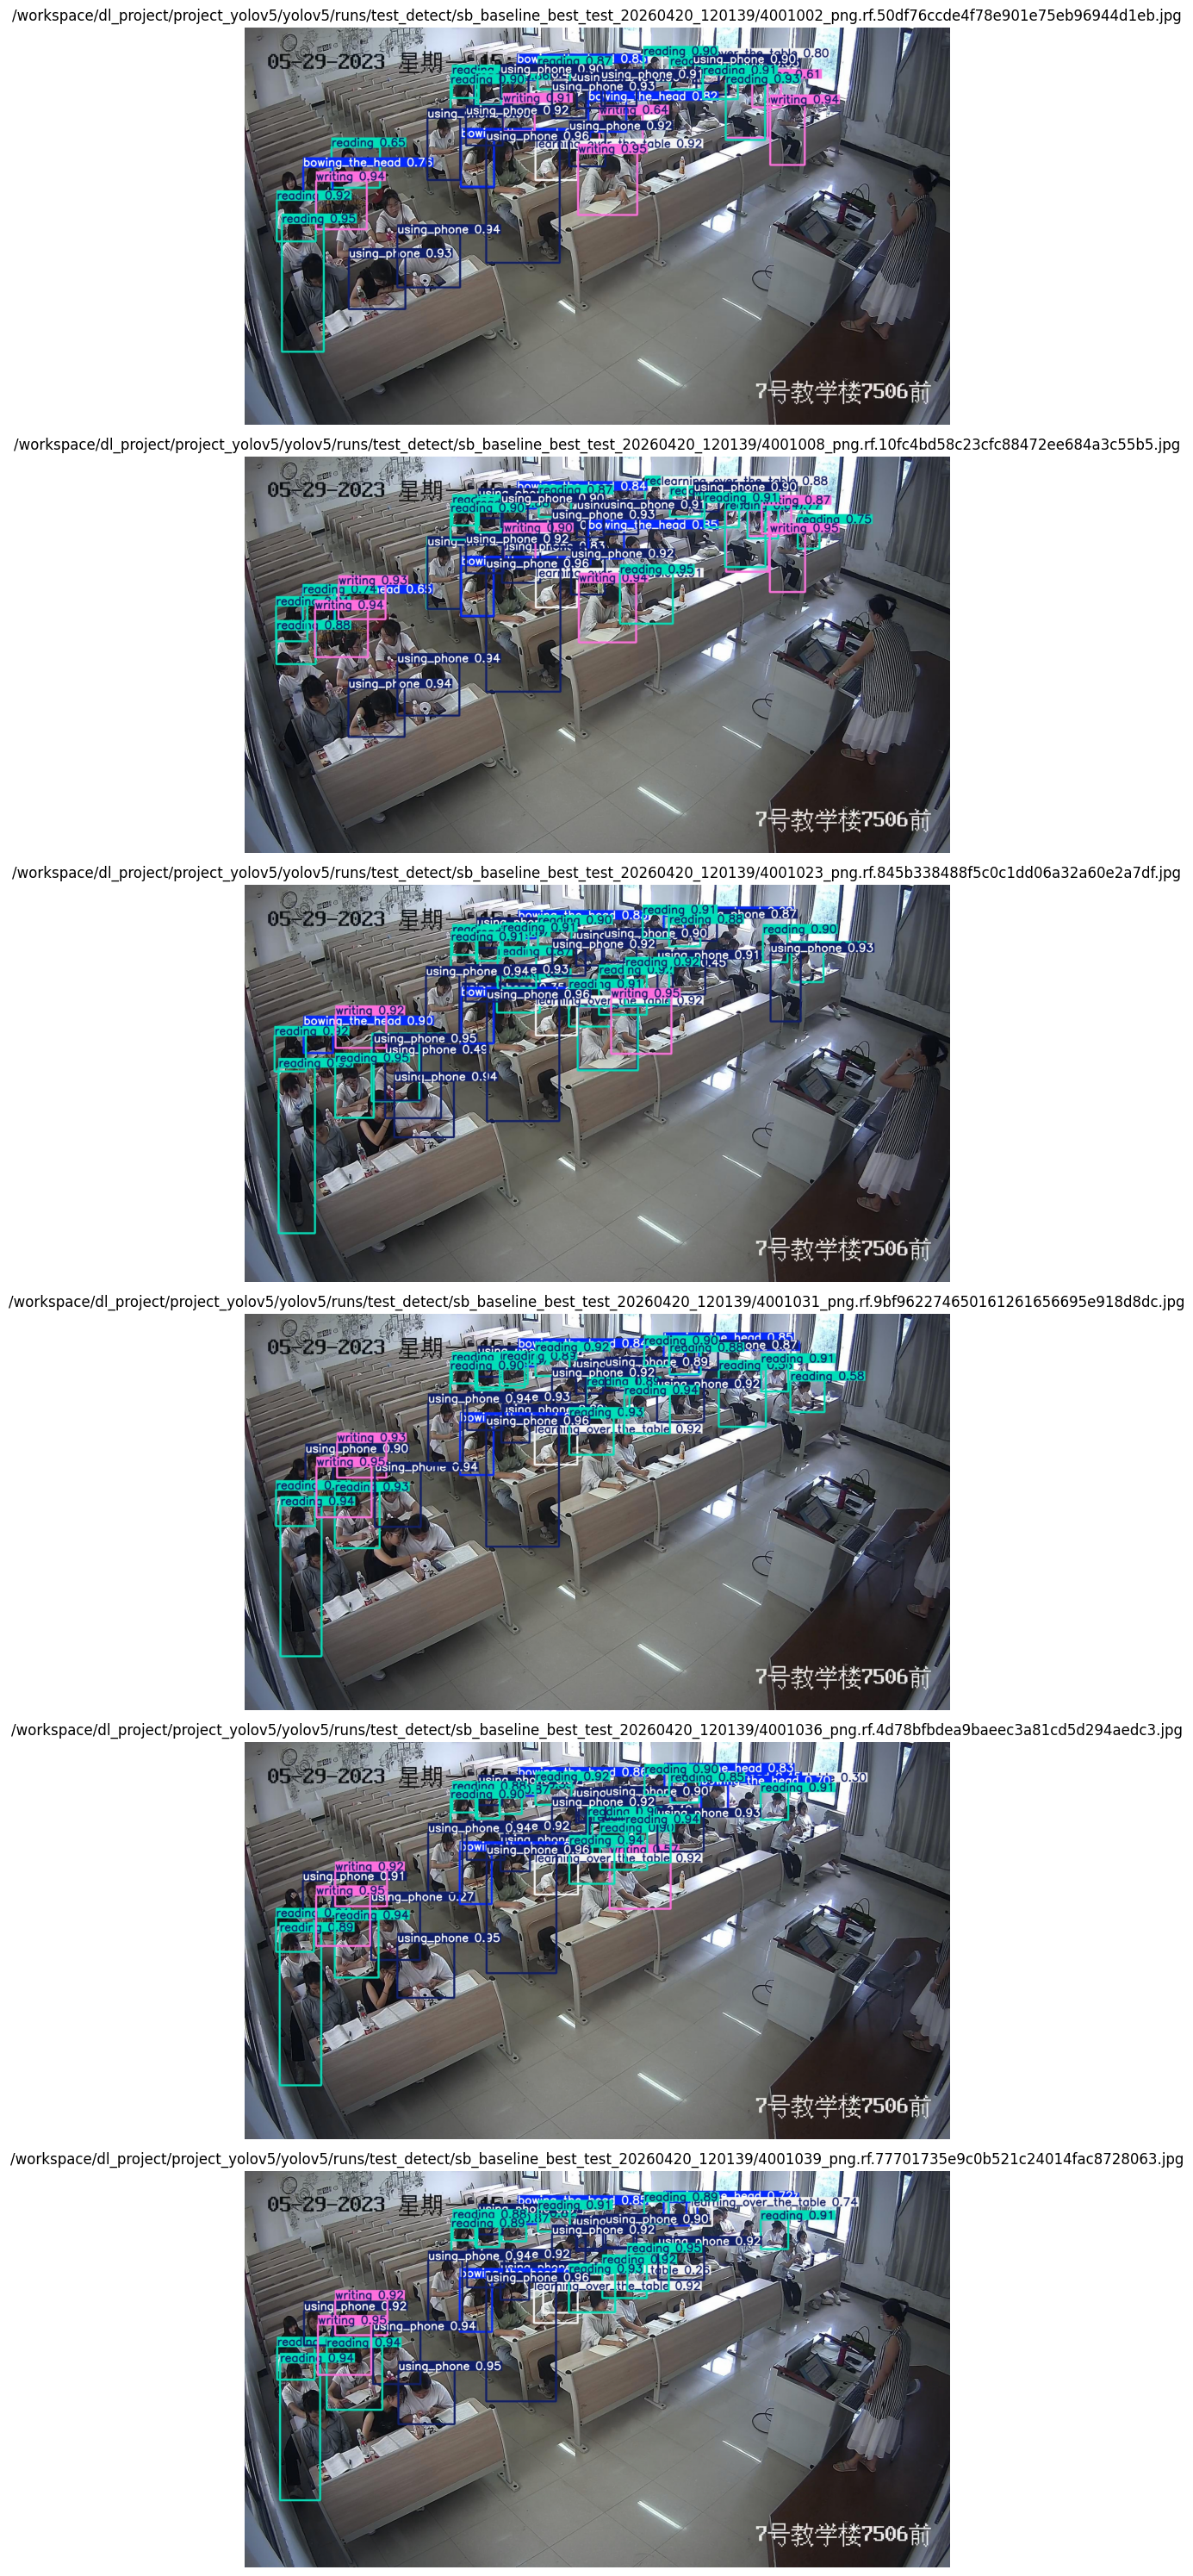

In [40]:
image_paths = []

# Collect prediction images from detect outputs
for item in detect_results:
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(sorted(item["output_dir"].glob(ext)))

assert image_paths, "No prediction images found in runs/test_detect."

# Display the first several images in order
num_show = min(6, len(image_paths))
sample_paths = image_paths[:num_show]

fig, axes = plt.subplots(num_show, 1, figsize=(12, 5 * num_show))
if num_show == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(str(img_path))
    ax.axis("off")

plt.tight_layout()
plt.show()
